# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [1]:
import numpy as np                      
import pandas as pd                     
import matplotlib.pyplot as plt        
import seaborn as sns                  
from scipy.io import loadmat           
from sklearn.svm import LinearSVC, SVC
%matplotlib inline

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [2]:
mat = loadmat('data/ejer_1_data1.mat')
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:43 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[1.9643  , 4.5957  ],
        [2.2753  , 3.8589  ],
        [2.9781  , 4.5651  ],
        [2.932   , 3.5519  ],
        [3.5772  , 2.856   ],
        [4.015   , 3.1937  ],
        [3.3814  , 3.4291  ],
        [3.9113  , 4.1761  ],
        [2.7822  , 4.0431  ],
        [2.5518  , 4.6162  ],
        [3.3698  , 3.9101  ],
        [3.1048  , 3.0709  ],
        [1.9182  , 4.0534  ],
        [2.2638  , 4.3706  ],
        [2.6555  , 3.5008  ],
        [3.1855  , 4.2888  ],
        [3.6579  , 3.8692  ],
        [3.9113  , 3.4291  ],
        [3.6002  , 3.1221  ],
        [3.0357  , 3.3165  ],
        [1.5841  , 3.3575  ],
        [2.0103  , 3.2039  ],
        [1.9527  , 2.7843  ],
        [2.2753  , 2.7127  ],
        [2.3099  , 2.9584  ],
        [2.8283  , 2.6309  ],
        [3.0473  , 2.2931  ],
        [2.4827  , 2.0373  ],
        [2.5057 

In [3]:
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

In [4]:
mat['y']

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1]], dtype=uint8)

#### 3. Create a DataFrame with the features and target

In [5]:
df = pd.DataFrame(mat['X'], columns=['x1', 'x2'])
df['y'] = mat['y'].ravel()
df.head()

,x1,x2,y
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


In [6]:
# info del df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      51 non-null     float64
 1   x2      51 non-null     float64
 2   y       51 non-null     uint8  
dtypes: float64(2), uint8(1)
memory usage: 999.0 bytes


In [7]:
# describe del df
df.describe()

,x1,x2,y
count,51.000000,51.000000,51.000000
mean,2.268780,3.132512,0.411765
std,0.928531,0.753256,0.497050
min,0.086405,1.617700,0.000000
25%,1.572550,2.636000,0.000000
50%,2.275300,3.070900,0.000000
75%,2.955050,3.531400,1.000000
max,4.015000,4.616200,1.000000


In [8]:
# value counts de las clases normalizado
df['y'].value_counts(normalize=True)

y
0    0.588235
1    0.411765
Name: proportion, dtype: float64

#### 4. Plot a scatterplot with the data

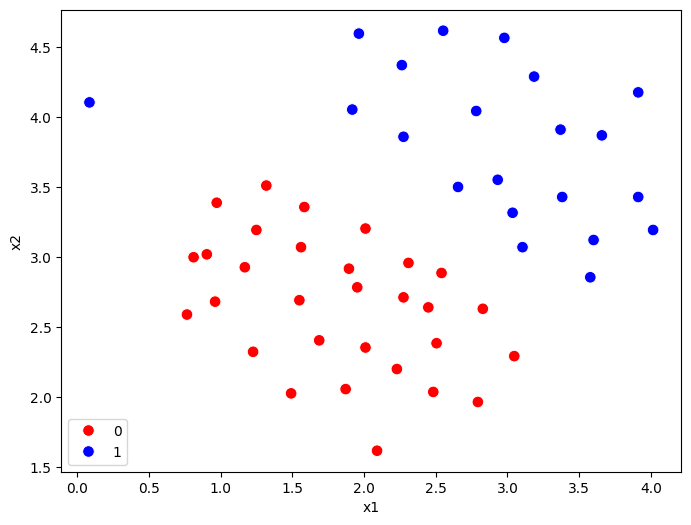

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette=['red', 'blue'], s=70)
plt.legend(loc='lower left')   # leyenda abajo a la izquierda
plt.show()

# pinta un scatter con los puntos y el color según la y
# pon la leyenda abajo a la izquierda

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [10]:
lSVC = LinearSVC(C=1, loss="hinge", max_iter=10000)

#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [11]:
# no hace falta separar en train y en test por simplicidad
# entrena el modelo con X, y
# calcula el score por defecto del modelo

X = df[["x1", "x2"]]
y = df["y"]

lSVC.fit(X, y)

lSVC.score(X, y)

0.9803921568627451

It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [12]:
# equivalente a lo anterior pero subiendo el hiperparámetro C
lSVC2 = LinearSVC(C=350, loss="hinge", max_iter=10000)
lSVC2.fit(X, y)

lSVC2.score(X, y)

C:\Users\juan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


1.0

This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

In [13]:
# obtén la función de decisión del modelo
funcion_decision = lSVC.decision_function(X)
funcion_decision

array([ 0.80274032,  0.38382682,  1.3773912 ,  0.52108269,  0.3333231 ,
        0.86861226,  0.68643477,  1.61110845,  0.83439082,  1.16703569,
        1.07314574,  0.22972569,  0.33174028,  0.79571687,  0.31571379,
        1.2739944 ,  1.21009841,  0.99988435,  0.56466144,  0.38981061,
       -0.43530064, -0.30887372, -0.68627845, -0.55403806, -0.33253008,
       -0.29385613, -0.44071289, -0.98399381, -0.68564174, -1.32848747,
       -1.0038036 , -1.49232493, -0.61144281, -0.68347202, -1.00005963,
       -1.15275873, -1.57842372, -1.35600897, -1.03242629, -1.18507432,
       -0.77144827, -0.7669569 , -0.46653724, -1.        , -0.5103491 ,
       -0.85863779, -1.55902735, -0.2549102 , -1.11367992, -1.54721908,
       -0.71000196])

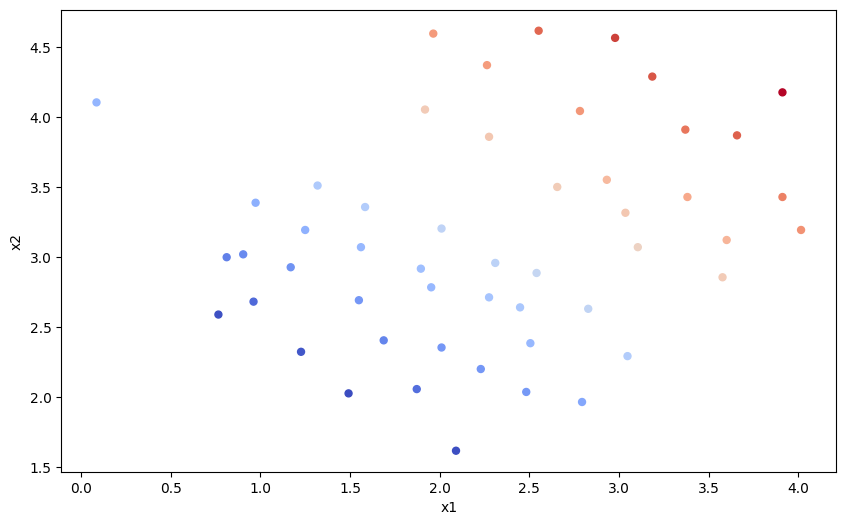

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['x1'], df['x2'], c=funcion_decision, cmap='coolwarm', s=25)
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

# usa un scatter para pintar los puntos, usa en el parámetro c del scatterplot la función de decisión
# el color puede ser "coolwarm"

#### 9. Do the same with the second model

In [15]:
# equivalente pero con el segundo modelo
funcion_decision2 = lSVC2.decision_function(X)
funcion_decision2

array([  8.59626184,   4.2708935 ,  11.14609158,   3.90613335,
         0.77932878,   4.34441349,   4.26942519,  10.95959479,
         6.94660887,  10.34234914,   7.61515997,   1.        ,
         4.66275453,   7.83246277,   2.79330084,   9.77162696,
         8.11364314,   5.71449216,   2.71048722,   2.53605468,
        -1.13465598,  -1.05089578,  -4.15421927,  -3.77721444,
        -1.9576619 ,  -2.8435158 ,  -4.61817229,  -7.95398223,
        -5.44775831,  -9.47588286,  -7.01430363,  -9.36624107,
        -3.37672854,  -3.21002903,  -5.89975143,  -7.53497765,
       -10.72756917,  -7.57421886,  -5.2844059 ,  -5.75549415,
        -2.58493674,  -3.19589632,  -0.78021906,  -7.49586214,
        -3.8084499 ,  -7.6090407 , -11.96841512,  -1.83279379,
        -5.35941553,  -8.75499812,   0.02614854])

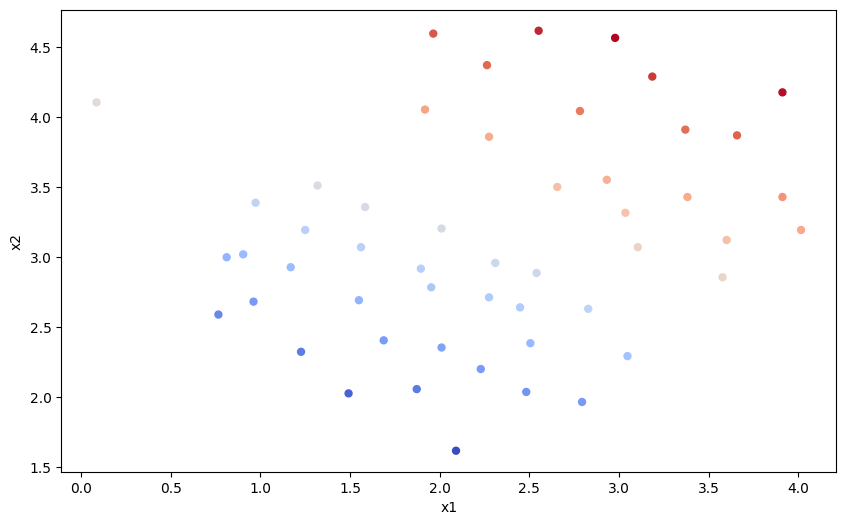

In [16]:
# equivalente con el segundo modelo
plt.figure(figsize=(10, 6))
plt.scatter(df['x1'], df['x2'], c=funcion_decision2, cmap='coolwarm', s=25)
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

y = ax1 + bx2 + c

0 = ax1 + bx2 + c

x2 = -ax1/b - c/b

In [17]:
# coeficientes del segundo modelo
lSVC2.coef_

array([[2.72705599, 7.0215564 ]])

In [18]:
# intercept del segundo modelo
lSVC2.intercept_

array([-29.02946098])

In [19]:
a = lSVC2.coef_[0][0]
b = lSVC2.coef_[0][1]
c = lSVC2.intercept_

In [20]:
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

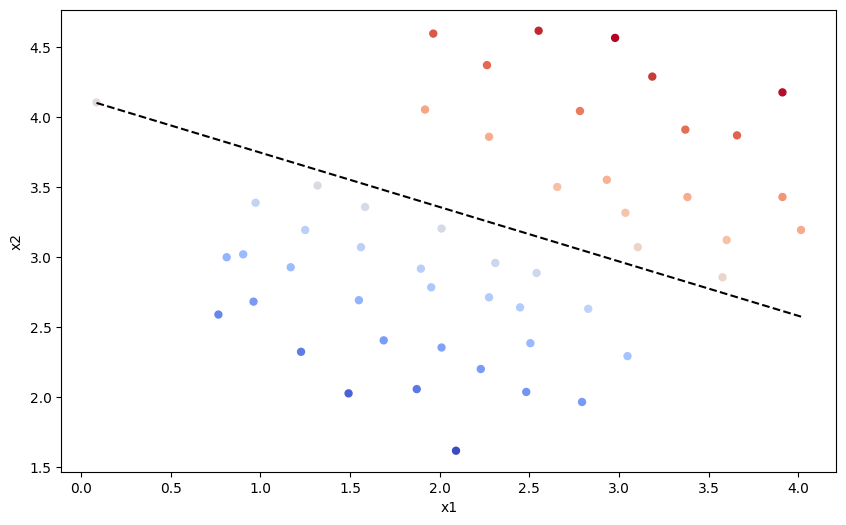

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df['x1'], df['x2'], c=funcion_decision2, cmap='coolwarm', s=25)
plt.plot(x_points, y_points, 'k--', label='Frontera de decisión')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

# pinta los puntos con su nivel de confianza
# añade la recta que es la frontera de separación

In [22]:
a = lSVC.coef_[0][0]
b = lSVC.coef_[0][1]
c = lSVC.intercept_
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

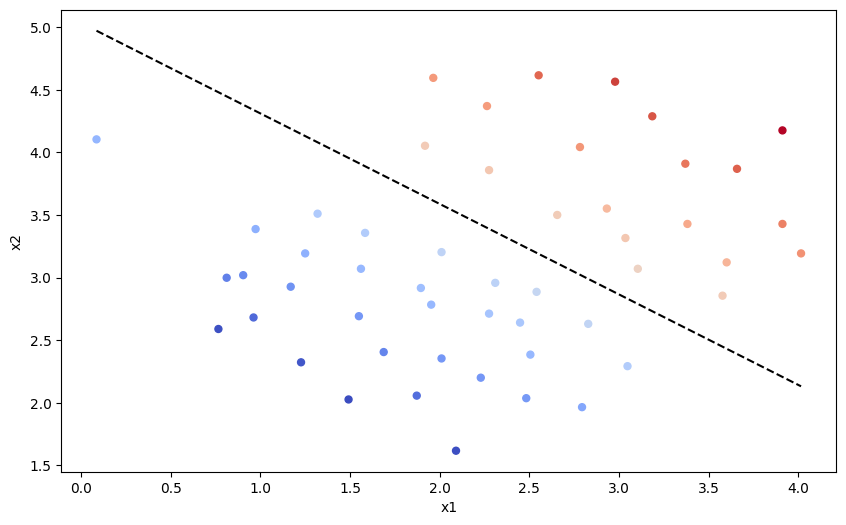

In [23]:
# equivalente con el modelo 1
plt.figure(figsize=(10, 6))
plt.scatter(df['x1'], df['x2'], c=funcion_decision, cmap='coolwarm', s=25)
plt.plot(x_points, y_points, 'k--', label='Frontera de decisión')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

Now we're going to move from a linear SVM to one that's capable of non-linear classification using kernels.  We're first tasked with implementing a gaussian kernel function.  Although scikit-learn has a gaussian kernel built in, for transparency we'll implement one from scratch.

## Exercise 2

That result matches the expected value from the exercise.  Next we're going to examine another data set, this time with a non-linear decision boundary.

#### 1. Load the data `ejer_1_data2.mat`

In [24]:
# descarga los datos y mira sus claves
mat = loadmat('data/ejer_1_data2.mat')
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

#### 2. Create a DataFrame with the features and target

In [25]:
# crea el df
# muestra su head
df = pd.DataFrame(mat['X'], columns=['x1', 'x2'])
df['y'] = mat['y'].ravel()
df.head()

,x1,x2,y
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1


In [26]:
# la info del df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      863 non-null    float64
 1   x2      863 non-null    float64
 2   y       863 non-null    uint8  
dtypes: float64(2), uint8(1)
memory usage: 14.5 KB


In [27]:
# describe del df
df.describe()

,x1,x2,y
count,863.000000,863.000000,863.000000
mean,0.503414,0.694304,0.556199
std,0.254967,0.158884,0.497120
min,0.044931,0.402632,0.000000
25%,0.292627,0.557018,0.000000
50%,0.512673,0.693713,1.000000
75%,0.699309,0.830409,1.000000
max,0.998848,0.988596,1.000000


#### 3. Plot a scatterplot with the data

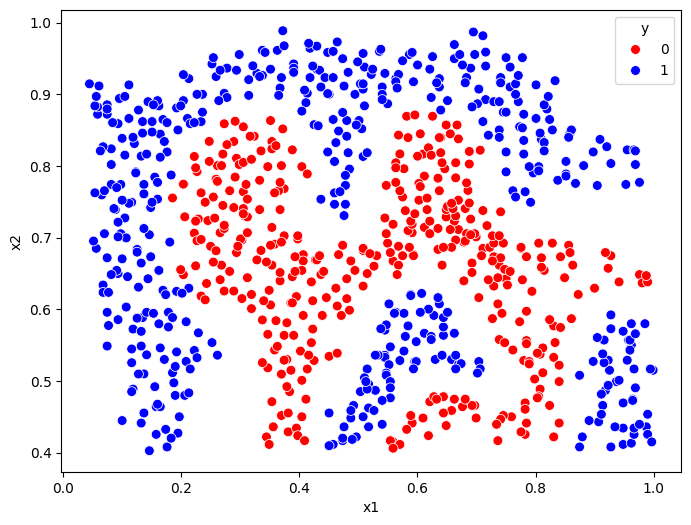

In [42]:
# scatterplot y en hue la y
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette=['red', 'blue'], s=50)
plt.show()

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

Score:  0.5538818076477404


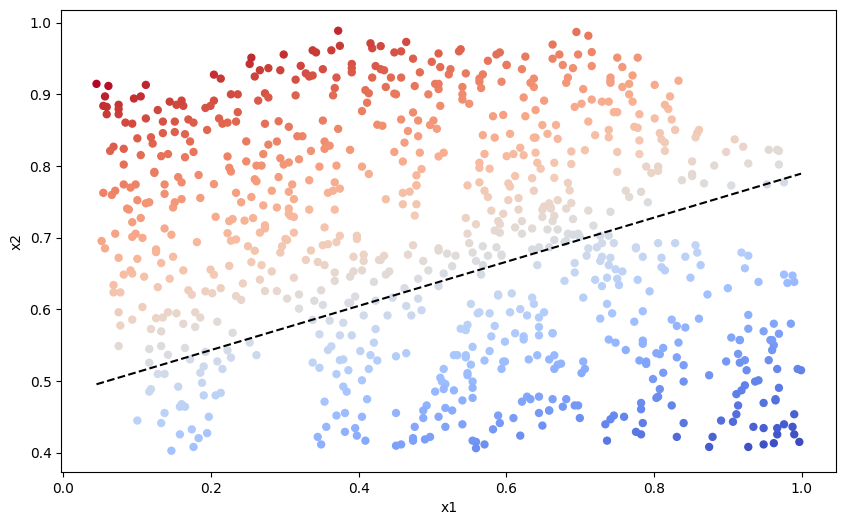

In [29]:
# haz un svc con C = 1, loss = "hinge" y max_iter = 10000
# entrénalo y calcula su score por defecto
X= df[["x1", "x2"]]
y = df["y"]

lSVC3 = LinearSVC(C=1, loss= "hinge", max_iter=10000)
lSVC3.fit(X, y)
print("Score: ", lSVC3.score(X, y))

a = lSVC3.coef_[0][0]
b = lSVC3.coef_[0][1]
c = lSVC3.intercept_
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

funcion_decision3 = lSVC3.decision_function(X)

plt.figure(figsize=(10, 6))
plt.scatter(df['x1'], df['x2'], c=funcion_decision3, cmap='coolwarm', s=25)
plt.plot(x_points, y_points, 'k--', label='Frontera de decisión')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()
# saca el nivel de confianza
# pinta un scatter con ese nivel de confianza y color "coolwarm"
# pinta la frontera de separación de las clases

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [31]:
lsvc4 = SVC(C=100, gamma=10, probability=True)

#### 5. Fit the classifier and get the score

In [32]:
lsvc4.fit(X,y)
lsvc4.score(X,y)

0.9698725376593279

#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

In [34]:
# pista: tienes que obtener la probabilidad de ser 0
y_pred_proba = lsvc4.predict_proba(X)
y_pred_proba

array([[3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       ...,
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00]], shape=(863, 2))

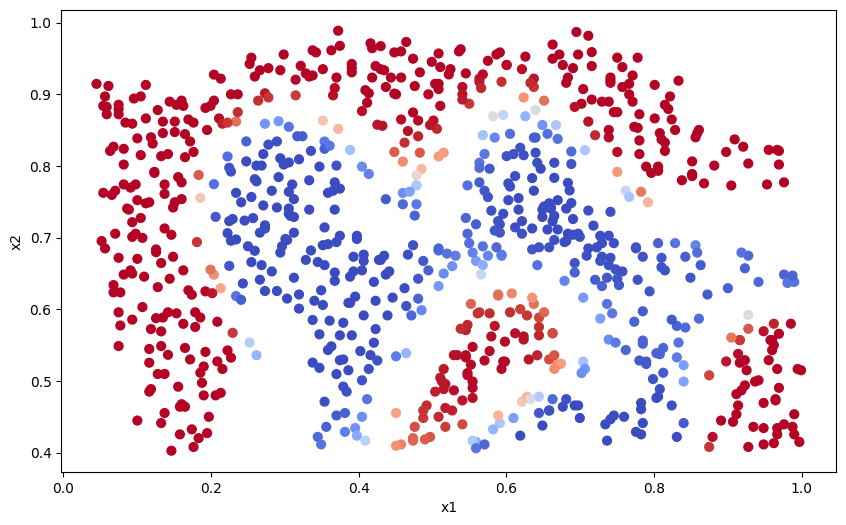

In [37]:
# haz un scatter para los puntos y pon el color según la probabilidad de ser 1
plt.figure(figsize=(10, 6))
plt.scatter(df['x1'], df['x2'], c=y_pred_proba[:, 1], cmap='coolwarm', s=40)
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

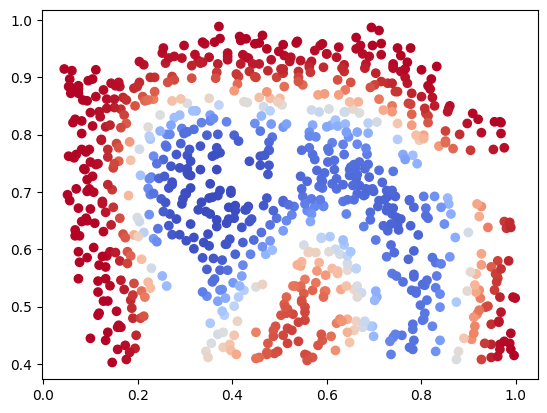

In [38]:
svc_5 = SVC(C=1, gamma=10, probability=True)
svc_5.fit(X, y)
svc_5.score(X, y)
y_pred_proba = svc_5.predict_proba(X)
plt.scatter(df['x1'], df['x2'], c=y_pred_proba[:,1], cmap="coolwarm")

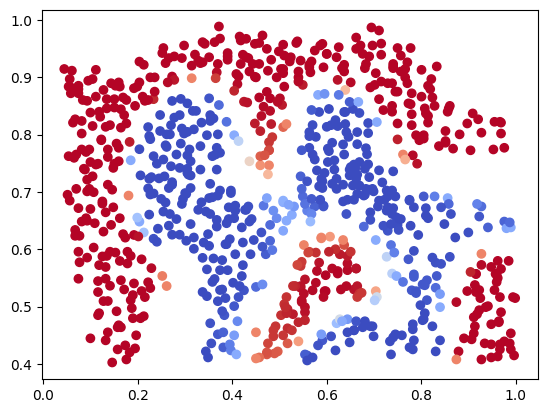

In [40]:
svc_6 = SVC(C=10000, gamma=10, probability=True)
svc_6.fit(X, y)
svc_6.score(X, y)
y_pred_proba = svc_6.predict_proba(X)
plt.scatter(df['x1'], df['x2'], c=y_pred_proba[:,1], cmap="coolwarm")
# equivalente

In [41]:
# importa train_test_split y GridSearchCV
from sklearn.model_selection import train_test_split, GridSearchCV

# divide en train y en test con semilla de 42 y 20% para el test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (690, 2), Test: (173, 2)


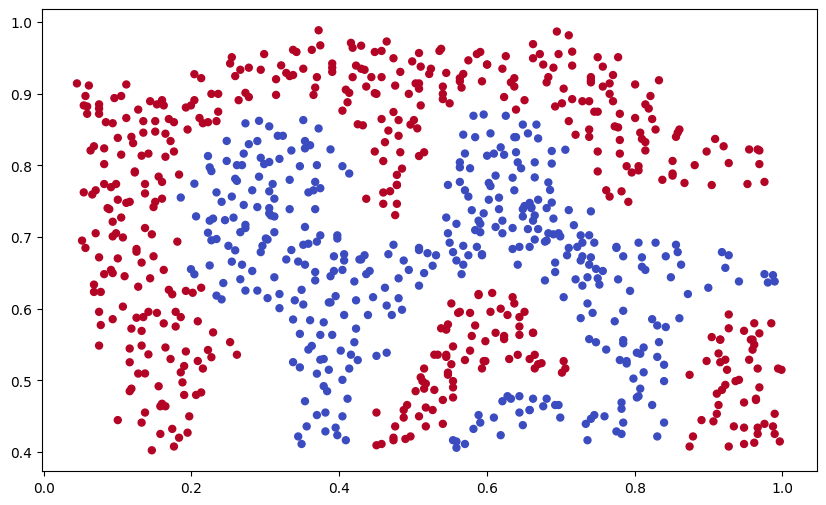

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(X['x1'], X['x2'], c=y, cmap='coolwarm', s=25)
plt.show()
# haz un scatter con todo X, el color viene de y y el color es "coolwarm"

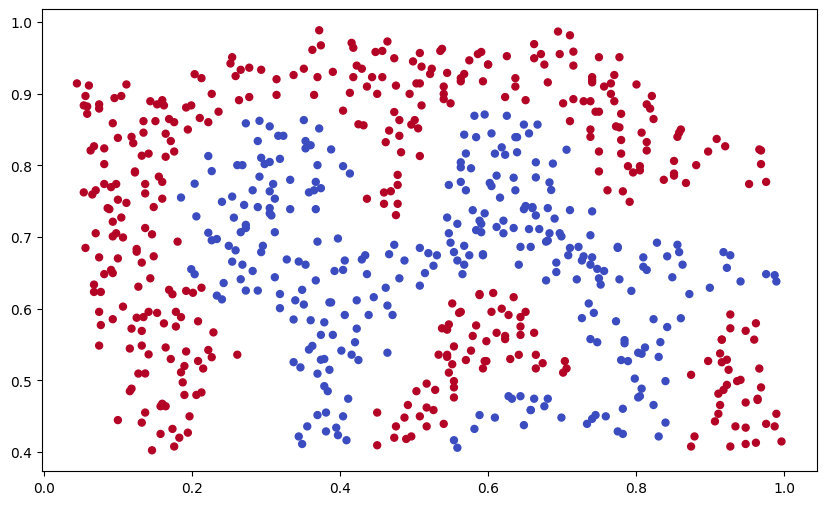

In [46]:
# equivalente con X train
plt.figure(figsize=(10, 6))
plt.scatter(X_train['x1'], X_train['x2'], c=y_train, cmap='coolwarm', s=25)
plt.show()

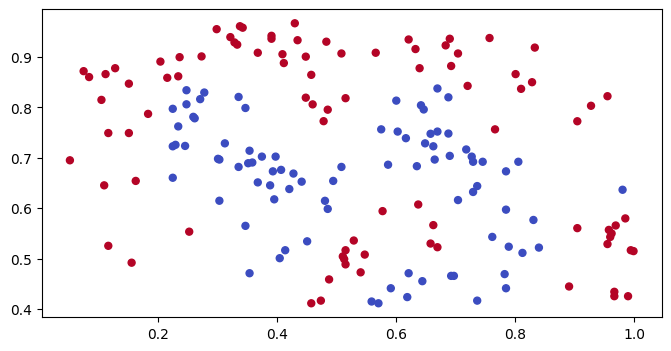

In [50]:
# equivalente con X test
plt.figure(figsize=(8, 4))
plt.scatter(X_test['x1'], X_test['x2'], c=y_test, cmap='coolwarm', s=25)
plt.show()

In [51]:
# hiperparámetros: kernel rbf, kernel polynomial, C puede valer 1, 10, 50, 100
param_grid = {
    'C': [1, 10, 50, 100],
    'kernel': ['rbf', 'poly']
}

# haz un gridsearchcv con 5 folds, scoring accuracy y verbose 2, entrénalo con train
gs = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2
)
gs.fit(X_train, y_train)

print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.0s
[CV] END ...................................C=10, kernel=rbf; total time=   0.0s
[CV] END ...................................C=10,

In [53]:
# mira el score en test
gs.score(X_test,y_test)

0.9421965317919075

In [54]:
# usa pickle y guarda el estimador GridsearchCV en un archivo
import pickle

with open('final_model.pkl', 'wb') as f:
    pickle.dump(gs.best_estimator_, f)

In [55]:
# lee usando pickle el archivo
with open('final_model.pkl', 'rb') as f:
    modelo_importado = pickle.load(f)

In [56]:
modelo_importado

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [60]:
# predice [1,3]
modelo_importado.predict([[1, 3]])

C:\Users\juan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([1], dtype=uint8)

In [61]:
y_test_proba = modelo_importado.predict_proba(X_test)[:, 1]
y_test_proba[:10]
# Obtén las probabilidades de ser 1 en test

array([9.75818417e-01, 3.49055768e-01, 1.00000000e+00, 5.17567475e-03,
       2.64113404e-05, 9.99995839e-01, 3.09895498e-03, 1.42572909e-01,
       2.65895786e-02, 9.99998962e-01])

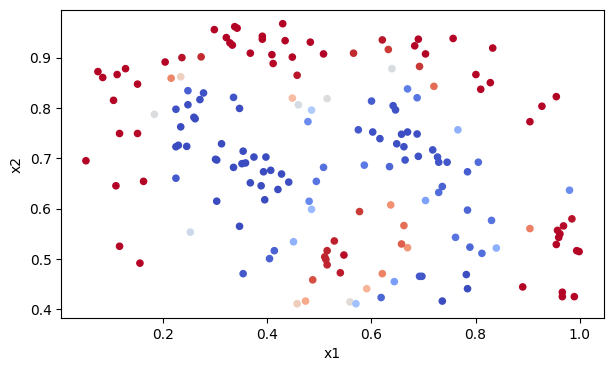

In [68]:
# haz un scatterplot y pinta esos puntos de test con sus probabilidades de ser 1
plt.figure(figsize=(7, 4))
plt.scatter(X_test['x1'], X_test['x2'], c=y_test_proba, cmap='coolwarm', s=20)
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

In [69]:
# EXTRA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
# usa pipeline y PolynomialFeatures
pipe = Pipeline([
    ('polynomial', PolynomialFeatures()),
    ('classifier', LinearSVC(max_iter=100000))
])
# prueba grados de 2 a 6
# el hiperparámetro C del svc entre -1 y 2, 5 valor espaciados logarítmicamente
param_grid = {
    'polynomial__degree': [2, 3, 4, 5],
    'classifier__C': np.logspace(-1, 2, 5)
}
# 5 folds
gs = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', verbose=2)
gs.fit(X_train, y_train)

# scoring accuracy
print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)
final_model.score(X_test, y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ............classifier__C=0.1, polynomial__degree=2; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=2; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=2; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=2; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=2; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=3; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=3; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=3; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=3; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=3; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=4; total time=   0.0s
[CV] END ............classifier__C=0.1, polynom

0.8323699421965318

In [70]:
# con pipelines y GridSearchCV
pipe = Pipeline([
    ('polynomial', PolynomialFeatures()),
    ('classifier', SVC(probability=True))
])
# polynomial puede ser grado 2, 3 o Ninguno
# C del svc espaciado logarítmico entre -1 y 2, 5 valores
# el kernel del svc lineal o gaussiano
param_grid = [
    {
        'polynomial': [PolynomialFeatures(degree=2), PolynomialFeatures(degree=3), 'passthrough'],
        'classifier__C': np.logspace(-1, 2, 5),
        'classifier__kernel': ['linear', 'rbf']
    }
]

# 5 folds, scoring accuracy, verbose 2
gs = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', verbose=2)
gs.fit(X_train, y_train)



print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)
final_model.score(X_test, y_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(degree=3); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(degree=3); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(degree=3); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, pol

0.9421965317919075